# Aligning two MERFISH sections

Two replicate sections of the same tissue brought into a common frame, entirely through
squidpy's public API: `align_stalign_obs` fits a diffeomorphism directly between two point
clouds, rasterizing both sides itself.

Upstream's equivalent is `merfish-merfish-alignment`, which rotates the source by hand before
rasterizing. Here the paired landmarks supply the starting affine instead.

## Inputs

In [1]:
import anndata as ad, numpy as np, pandas as pd

MERFISH = 'merfish_data/datasets_mouse_brain_map_BrainReceptorShowcase_Slice2_Replicate'

def section(replicate):
    """One replicate's centroids as an AnnData, coordinates in microns."""
    df = pd.read_csv(f'{MERFISH}{replicate}_cell_metadata_S2R{replicate}.csv.gz')
    xy = np.c_[df['center_x'], df['center_y']].astype(float)
    return ad.AnnData(X=np.zeros((len(xy), 1)), obsm={'spatial': xy})

# S2R2 is the reference; S2R3 is the section that moves.
ref, query = section(2), section(3)

# Thirteen landmark pairs picked by hand, stored as `(x, y)` -- which is what squidpy's public
# API takes, so unlike upstream's own notebook nothing here transposes them on the way in.
landmarks = {r: np.asarray(np.load(f'merfish_data/Merfish_S2_R{r}_points.npy',
                                   allow_pickle=True).item()['all'], dtype=float)
             for r in (2, 3)}

# They stay plain arrays: landmarks are correspondences *between* the two sections rather
# than observations *of* either, so they have no `obs` axis to hang off -- and every
# function here takes them as arrays.
print(f'{ref.n_obs} reference cells, {query.n_obs} query cells, '
      f'{len(landmarks[2])} landmark pairs')

84172 reference cells, 85958 query cells, 13 landmark pairs


## The fit

Handing over the landmarks does two separate things: they derive the starting affine, and they
stay in the objective as a matching term weighted by `sigmaP` -- so the fit is pulled toward
them rather than merely started there.

`dx` and `blur` are the rasterization the solver does internally; upstream's notebook uses
30 um and 1.5, and `epV=50` is its one departure from the solver defaults.

In [2]:
from squidpy.experimental.tl import align_stalign_obs

fit = align_stalign_obs(
    ref, query, spatial_key='spatial',
    landmarks_ref=landmarks[2], landmarks_query=landmarks[3],
    dx=30.0, blur=1.5, niter=10000, epV=50,
)
print(f'{fit.n_iter} iterations, objective '
      f'{float(fit.energies[0]):.0f} -> {float(fit.energies[-1]):.0f}')

/localscratch/selman.ozleyen/stalign-nb-39784298/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


10000 iterations, objective 4322 -> 2512


## Where the cells land

`transform` evaluates the fitted map at each point, so a cell lands where it lands rather than
at the nearest raster cell. The middle panel is what the landmark affine alone achieves, for
comparison -- the difference between the two is what the diffeomorphism bought.

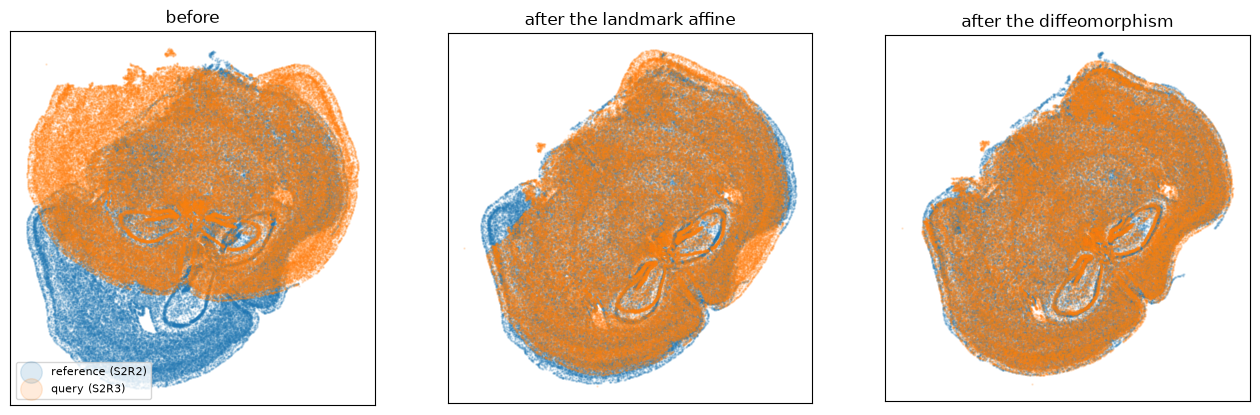

In [3]:
import matplotlib.pyplot as plt
from squidpy.experimental.tl import align_landmarks

moved = np.asarray(fit.transform(query.obsm['spatial']))
affine = align_landmarks(landmarks[2], landmarks[3], fit='affine')
affine_only = query.obsm['spatial'] @ affine[:2, :2].T + affine[:2, 2]

fig, ax = plt.subplots(1, 3, figsize=(16, 5.5))
for a, (pts, title) in zip(ax, [
        (query.obsm['spatial'], 'before'),
        (affine_only, 'after the landmark affine'),
        (moved, 'after the diffeomorphism')], strict=True):
    a.scatter(*ref.obsm['spatial'].T, s=0.6, alpha=0.15, label='reference (S2R2)')
    a.scatter(*pts.T, s=0.6, alpha=0.15, label='query (S2R3)')
    a.set_title(title); a.set_aspect('equal'); a.invert_yaxis()
    a.set_xticks([]); a.set_yticks([])
ax[0].legend(markerscale=20, loc='lower left', fontsize=8)

The objective's own trace. As in the volume notebooks, the mixture E step switches on at
iteration 50 and the energy changes definition there, so only the part after the dashed line
is one function.

after the gate: 4844 -> 2512, minimum 2512 at iteration 9999
last tenth: mean 2532, spread 42 (1.6% of its mean)


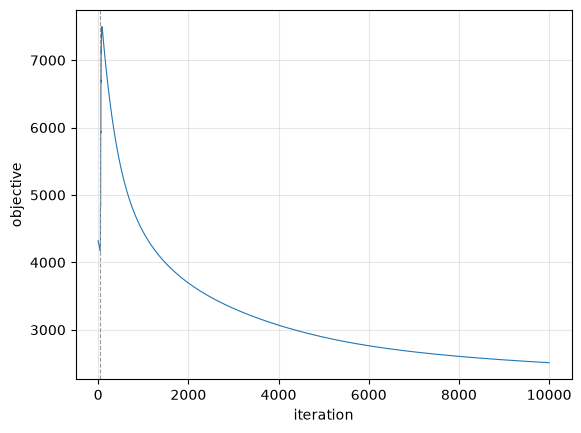

In [4]:
MIXTURE_GATE = 50
energies = np.asarray(fit.energies)[: fit.n_iter]
descent = energies[MIXTURE_GATE + 1 :]
tail = descent[-len(descent) // 10 :]
print(f'after the gate: {descent[0]:.0f} -> {descent[-1]:.0f}, minimum {descent.min():.0f} '
      f'at iteration {MIXTURE_GATE + 1 + int(descent.argmin())}')
print(f'last tenth: mean {tail.mean():.0f}, spread {np.ptp(tail):.0f} '
      f'({100 * np.ptp(tail) / tail.mean():.1f}% of its mean)')
plt.plot(energies, lw=0.8); plt.axvline(MIXTURE_GATE, color='0.6', ls='--', lw=0.8)
plt.xlabel('iteration'); plt.ylabel('objective'); plt.grid(alpha=0.3)